In [2]:
import gzip, random, pandas as pd
from pathlib import Path
import sklearn
import numpy as np
import matplotlib.pyplot as plt
import re

base = Path.home() / "Downloads" / "4650046_files"

In [3]:
import pandas as pd

tags = pd.read_csv(
    base /"tag_freqs_lcs.csv.gz",
    sep=",",
    compression="gzip",
)
print(tags.shape)

(7105651, 2)


In [4]:
tags.head()

,tag,freq
0,NaN,400239
1,education,157522
2,tutorial,156252
3,how to,119834
4,english,107078


In [5]:
tags.fillna("endersari").sort_values(by="freq",ascending=False).query("tag.str.contains('pandas')", engine="python")

,tag,freq
21647,pandas,293
44799,kape't pandasal,124
87426,pandas in telugu,53
137194,five little pandas,30
156696,python pandas,25
...,...,...
3769298,learn about pandas,1
3545346,apply lambda pandas,1
3507374,five little pandas song,1
3618590,pandas wheels on the bus,1


In [6]:
LANG_PATTERNS = {
    "JavaScript":   r"\b(?:javascript|java[\s-]?script|js)\b",
    "Python":       r"\bpython(?:\s*\d+)?\b",
    "HTML / CSS":   r"\bhtml(?:5)?\b|(?:\bcss(?:3)?\b)|\bhtml\s*/\s*css\b",
    "SQL":          r"\bsql\b|\bmy\s*sql\b|\bpostgres(?:ql)?\b|\bsqlite\b|\btsql\b|\bpl/?sql\b",
    "Java":         r"\bjava\b(?!\s*script)",
    "TypeScript":   r"\btypescript\b",
    "Shell":        r"\b(?:shell|bash|zsh|fish|powershell|pwsh)\b",
    "C++":          r"\bc\+\+\b|\bcpp\b|\bc\+\+\d+\b",
    "C#":           r"\bc\#\b|\bcsharp\b",
    "C":            r"\bc\b(?!\+\+|\#)\b", 
    "Go":           r"\bgolang\b|\bgo\b(?!\s*(to|away|out|for))", 
    "PHP":          r"\bphp\b",
    "Kotlin":       r"\bkotlin\b",
    "Rust":         r"\brust\b",
    "Dart":         r"\bdart(?:lang)?\b(?!\s*(board|game|mouth))",
    "Swift":        r"\bswift\b",
    "Lua":          r"\blua\b",
    "Ruby":         r"\bruby\b",
    "Scala":        r"\bscala\b",
    "Objective-C":  r"\bobjective[\s-]?c\b|\bobj[\s-]?c\b|\bobjc\b",
}

def rows_for_language(tags: pd.DataFrame, lang: str) -> pd.DataFrame:
    """
    Return rows where tags['tag'] matches the given language pattern.
    Assumes columns: 'tag', 'freq'.
    """
    pat = LANG_PATTERNS[lang]
    s = tags["tag"].astype("string")
    m = s.str.contains(pat, case=False, regex=True, na=False)
    return (
        tags.loc[m, ["tag", "freq"]]
            .sort_values(by="freq", ascending=False)
            .reset_index(drop=True)
    )

def totals_by_language(tags: pd.DataFrame) -> pd.DataFrame:
    """
    Sum 'freq' per language. A tag can match multiple languages; we count it for each match.
    """
    s = tags["tag"].astype("string")
    out = []
    for lang, pat in LANG_PATTERNS.items():
        m = s.str.contains(pat, case=False, regex=True, na=False)
        total = tags.loc[m, "freq"].sum()
        out.append((lang, int(total)))
    return (pd.DataFrame(out, columns=["language", "total_freq"])
              .sort_values(by="total_freq", ascending=False)
              .reset_index(drop=True))

def classify_top_language(tags: pd.DataFrame) -> pd.DataFrame:
    """
    Assign a single 'language' to each row based on the first pattern that matches
    (ordered by prevalence in LANG_PATTERNS). Non-matching rows get NaN.
    """
    s = tags["tag"].astype("string")
    lang_col = pd.Series(pd.NA, index=tags.index, dtype="string")
    for lang, pat in LANG_PATTERNS.items():
        m = s.str.contains(pat, case=False, regex=True, na=False)
        lang_col = lang_col.mask(lang_col.isna() & m, lang)
    out = tags.copy()
    out["language"] = lang_col
    return out


In [7]:
# --- examples ---
# python_rows = rows_for_language(tags, "Python")
# lang_totals  = totals_by_language(tags)

tagged = classify_top_language(tags)   # tags with a single best language label

/var/folders/4f/lgs40nxd3g3890_f8lsh6s8c0000gp/T/ipykernel_93837/1647781324.py:60: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  m = s.str.contains(pat, case=False, regex=True, na=False)
/var/folders/4f/lgs40nxd3g3890_f8lsh6s8c0000gp/T/ipykernel_93837/1647781324.py:60: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  m = s.str.contains(pat, case=False, regex=True, na=False)


In [8]:
tagged.language.value_counts(normalize=True)

language
HTML / CSS     0.180515
C              0.134951
JavaScript     0.109583
Java           0.098905
Python         0.091637
Go             0.091577
Shell          0.083824
SQL            0.070944
PHP            0.060479
Swift          0.034697
Kotlin         0.013152
Ruby           0.008594
Rust            0.00625
Dart           0.004889
Scala          0.003528
TypeScript     0.002592
Lua            0.001941
C++            0.001065
C#              0.00084
Objective-C    0.000036
Name: proportion, dtype: Float64

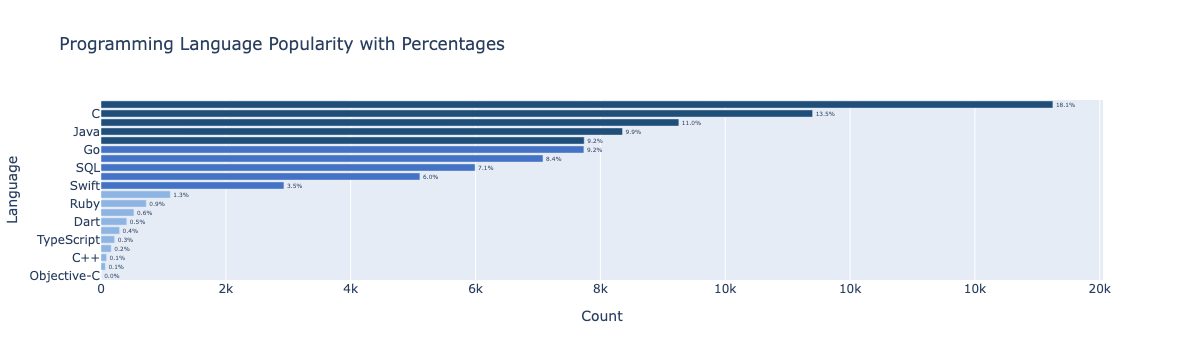

Chart saved as chart.png and chart.svg


In [18]:
import plotly.graph_objects as go

data_json = [{"Language":"HTML / CSS","Count":15249,"Tier":"Top 5"},{"Language":"C","Count":11400,"Tier":"Top 5"},{"Language":"JavaScript","Count":9257,"Tier":"Top 5"},{"Language":"Java","Count":8355,"Tier":"Top 5"},{"Language":"Python","Count":7741,"Tier":"Top 5"},{"Language":"Go","Count":7736,"Tier":"Next 5"},{"Language":"Shell","Count":7081,"Tier":"Next 5"},{"Language":"SQL","Count":5993,"Tier":"Next 5"},{"Language":"PHP","Count":5109,"Tier":"Next 5"},{"Language":"Swift","Count":2931,"Tier":"Next 5"},{"Language":"Kotlin","Count":1111,"Tier":"Others"},{"Language":"Ruby","Count":726,"Tier":"Others"},{"Language":"Rust","Count":528,"Tier":"Others"},{"Language":"Dart","Count":413,"Tier":"Others"},{"Language":"Scala","Count":298,"Tier":"Others"},{"Language":"TypeScript","Count":219,"Tier":"Others"},{"Language":"Lua","Count":164,"Tier":"Others"},{"Language":"C++","Count":90,"Tier":"Others"},{"Language":"C#","Count":71,"Tier":"Others"},{"Language":"Objective-C","Count":3,"Tier":"Others"}]

# Extract languages, counts, and tiers
languages = [item["Language"] for item in data_json]
counts = [item["Count"] for item in data_json]
tiers = [item["Tier"] for item in data_json]

languages = languages[::-1]
counts = counts[::-1] 
tiers = tiers[::-1]

# Calculate total count for percentages
total_count = sum(counts)

# Calculate percentages
percentages = [(count / total_count) * 100 for count in counts]

# Define colors for each tier
tier_colors = {
    "Top 5": "#1f4e79",      # Dark blue
    "Next 5": "#4472c4",     # Medium blue  
    "Others": "#8db4e2"      # Light blue
}

colors = [tier_colors[tier] for tier in tiers]

percentage_labels = [f"{percentage:.1f}%" for percentage in percentages]

def format_number(num):
    if num >= 1000000000:
        return f"{num/1000000000:.1f}b"
    elif num >= 1000000:
        return f"{num/1000000:.1f}m"
    elif num >= 1000:
        return f"{num/1000:.1f}k"
    else:
        return str(num)

formatted_counts = [format_number(count) for count in counts]

# Create the horizontal bar chart
fig = go.Figure(data=[
    go.Bar(
        y=languages,
        x=counts,
        orientation='h',
        marker_color=colors,
        text=percentage_labels,
        textposition='outside',
        hovertemplate='<b>%{y}</b><br>Count: %{customdata}<br>Percentage: %{text}<extra></extra>',
        customdata=formatted_counts
    )
])

# Update layout
fig.update_layout(
    title='Programming Language Popularity with Percentages',
    xaxis_title='Count',
    yaxis_title='Language'
)

fig.update_traces(cliponaxis=False)
fig.update_xaxes(tickformat='.0s')
fig.write_image("chart.png")
fig.write_image("chart.svg", format="svg")
fig.show()

print("Chart saved as chart.png and chart.svg")